# Descriptive Statistics

## Loading the Palmer Penguins dataset

In [4]:
import numpy as np
import pandas as pd

def load_palmer_penguins(no_missing=True):
    url = "https://raw.githubusercontent.com/"
    url += "allisonhorst/palmerpenguins/main/"
    url += "inst/extdata/penguins.csv"
    numeric_features = [
        "bill_length_mm", "bill_depth_mm",
        "flipper_length_mm", "body_mass_g"]
    target = ["species"]
    data = pd.read_csv(url)
    if no_missing:
        data = data.dropna()
    return data[numeric_features + target]
    
penguins = load_palmer_penguins(no_missing=True)


## Checking pandas and NumPy versions

In [5]:
print(f"Your pandas version is: {pd.__version__}")
print(f"Your NumPy version is {np.__version__}")

Your pandas version is: 3.0.2
Your NumPy version is 2.4.4


# The describe() shortcut

In [2]:
print(penguins.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


## Calculating means and medians

In [6]:
print(penguins.mean(numeric_only=True))

bill_length_mm         43.992793
bill_depth_mm          17.164865
flipper_length_mm     200.966967
body_mass_g          4207.057057
dtype: float64


In [7]:
print(penguins.median(numeric_only=True))

bill_length_mm         44.5
bill_depth_mm          17.3
flipper_length_mm     197.0
body_mass_g          4050.0
dtype: float64


# Get Started with MatPlotLib

# Importing MatPlotLib

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

## Your first plot

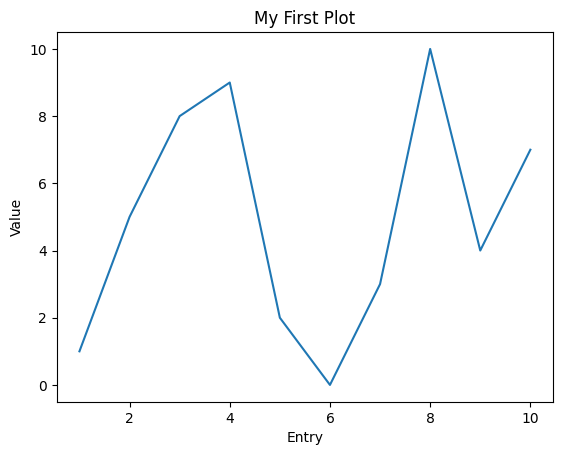

In [9]:
values = [1, 5, 8, 9, 2, 0, 3, 10, 4, 7]

plt.plot(range(1, 11), values)
plt.xlabel('Entry')
plt.ylabel('Value')
plt.title('My First Plot')
plt.show()


## Multiple lines and legends

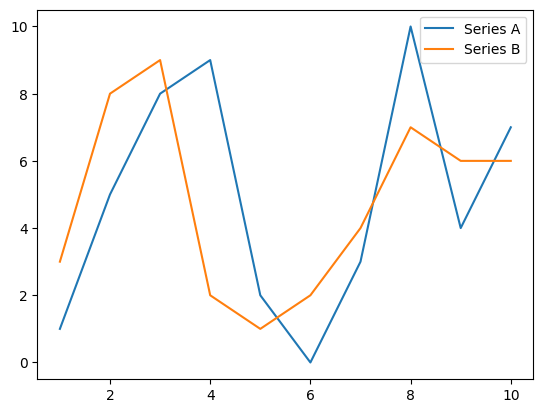

In [10]:
values1 = [1, 5, 8, 9, 2, 0, 3, 10, 4, 7]
values2 = [3, 8, 9, 2, 1, 2, 4, 7, 6, 6]

plt.plot(range(1, 11), values1, label='Series A')
plt.plot(range(1, 11), values2, label='Series B')
plt.legend()
plt.show()


## Saving your work

In [ ]:
import matplotlib.pyplot as plt
%matplotlib auto

values = [1, 5, 8, 9, 2, 0, 3, 10, 4, 7]
plt.plot(range(1,11), values)
plt.ioff()
plt.savefig('MySamplePlot.png', format='png')

## Creating bar charts

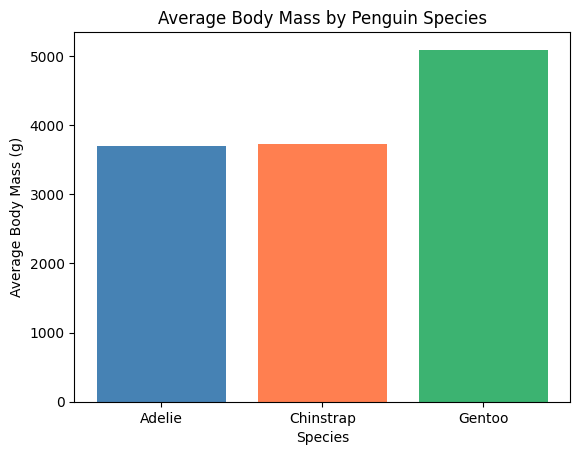

In [11]:
# Average body mass by species
species_mass = penguins.groupby('species')['body_mass_g'].mean()

plt.bar(species_mass.index, species_mass.values, color=['steelblue', 'coral', 'mediumseagreen'])
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass by Penguin Species')
plt.show()


## Creating histograms

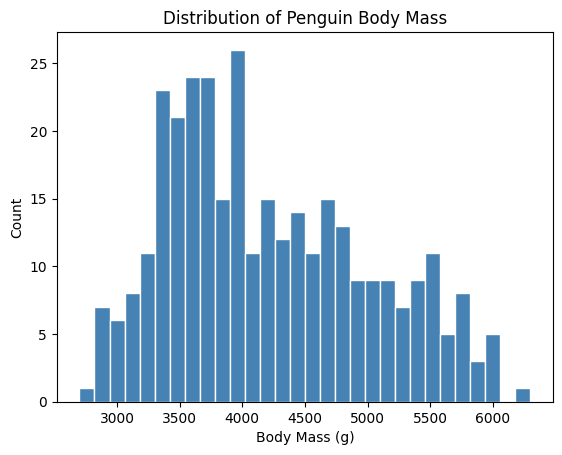

In [12]:
plt.hist(penguins['body_mass_g'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Body Mass (g)')
plt.ylabel('Count')
plt.title('Distribution of Penguin Body Mass')
plt.show()


## Creating boxplots

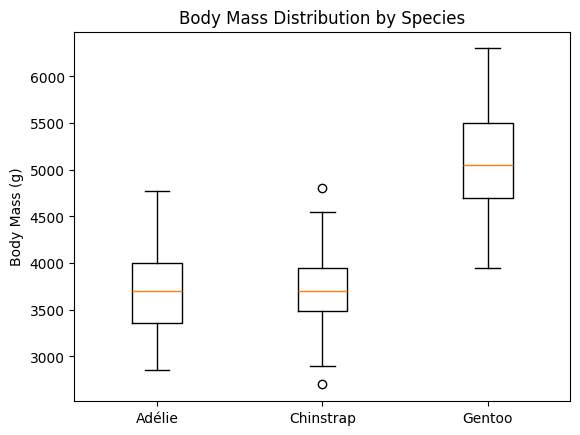

In [15]:
# Separate body mass values by species
adelie = penguins[penguins['species'] =='Adelie']['body_mass_g']
chinstrap = penguins[penguins['species'] =='Chinstrap']['body_mass_g']
gentoo = penguins[penguins['species'] =='Gentoo']['body_mass_g']

plt.boxplot([adelie, chinstrap, gentoo],
            tick_labels=['Adélie', 'Chinstrap', 'Gentoo'])
plt.ylabel('Body Mass (g)')
plt.title('Body Mass Distribution by Species')
plt.show()



## Scatterplots

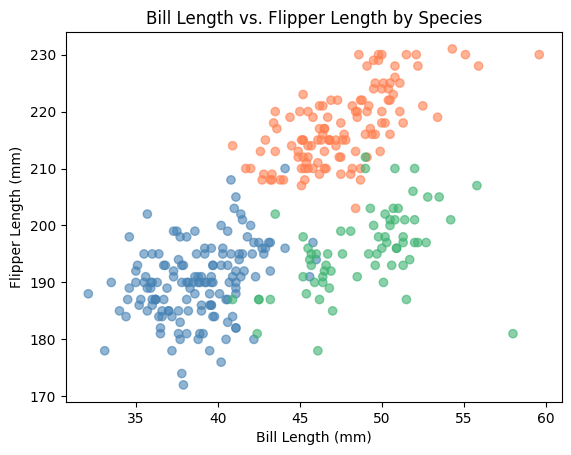

In [16]:
# Color each point by species
palette = {'Adelie': 'steelblue', 'Gentoo': 'coral', 'Chinstrap': 'mediumseagreen'}
colors = [palette[s] for s in penguins['species']]

plt.scatter(penguins['bill_length_mm'],
            penguins['flipper_length_mm'],
            c=colors, alpha=0.6)
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.title('Bill Length vs. Flipper Length by Species')
plt.show()

## Calculating the full correlation matrix

In [17]:
print(penguins.select_dtypes('number').corr().round(2))

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.23               0.65   
bill_depth_mm               -0.23           1.00              -0.58   
flipper_length_mm            0.65          -0.58               1.00   
body_mass_g                  0.59          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.59  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  


## Creating a heatmap

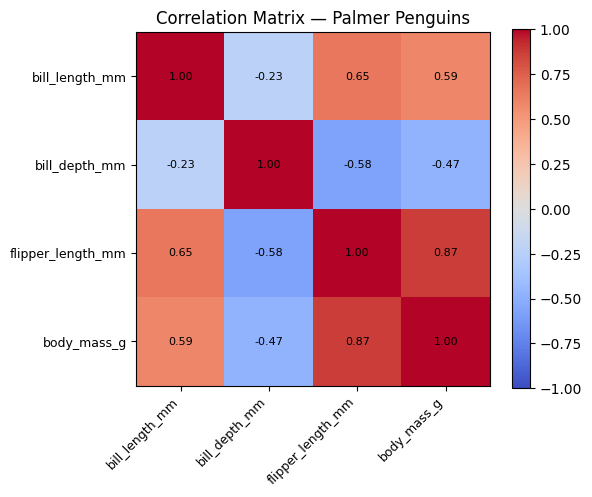

In [19]:
import matplotlib.pyplot as plt
import numpy as np

corr = penguins.select_dtypes('number').corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

labels = corr.columns
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Annotate each cell with its correlation value
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=8)

plt.title('Correlation Matrix — Palmer Penguins')
plt.tight_layout()
plt.show()


# Full EDA Workflow

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000

Missing values: 0


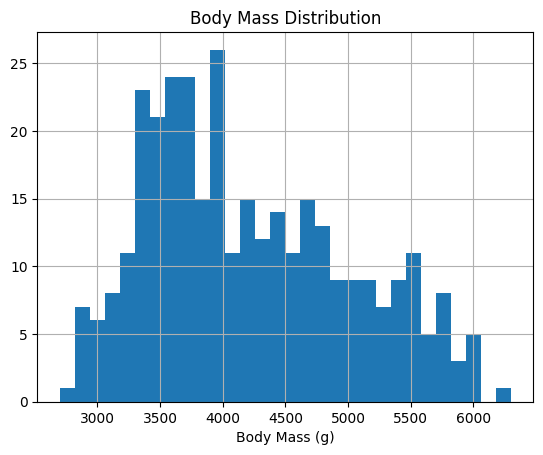

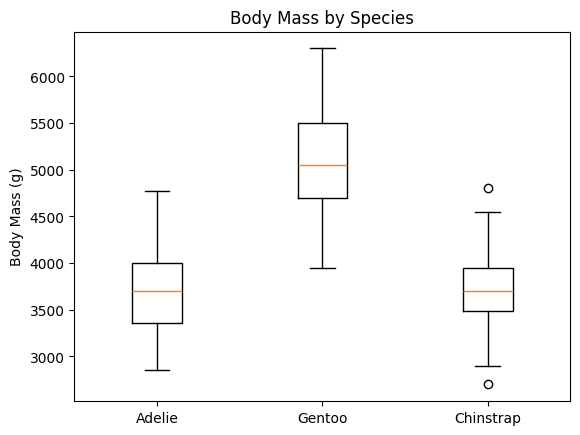

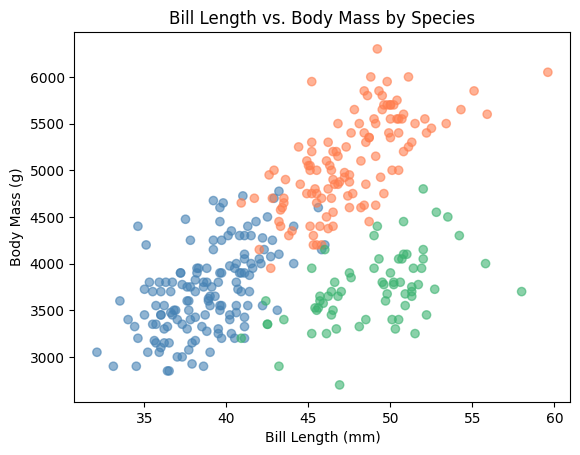


Correlation matrix:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.23               0.65   
bill_depth_mm               -0.23           1.00              -0.58   
flipper_length_mm            0.65          -0.58               1.00   
body_mass_g                  0.59          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.59  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
url = ("https://raw.githubusercontent.com/allisonhorst/"
"palmerpenguins/main/inst/extdata/penguins.csv")
penguins = pd.read_csv(url).dropna()
penguins = penguins[['bill_length_mm', 'bill_depth_mm',
'flipper_length_mm', 'body_mass_g', 'species']]

# 2. Describe the data
print(penguins.describe())
print("\nMissing values:", penguins.isnull().sum().sum())

# 3. Distribution of a key variable
penguins['body_mass_g'].hist(bins=30)
plt.title('Body Mass Distribution')
plt.xlabel('Body Mass (g)')
plt.show()

# 4. Compare groups with boxplot
groups = [penguins[penguins['species'] == s]['body_mass_g']
for s in penguins['species'].unique()]
plt.boxplot(groups, tick_labels=penguins['species'].unique())
plt.title('Body Mass by Species')
plt.ylabel('Body Mass (g)')
plt.show()

# 5. Explore a relationship
palette = {'Adelie': 'steelblue', 'Gentoo': 'coral', 'Chinstrap': 'mediumseagreen'}
colors = [palette[s] for s in penguins['species']]
plt.scatter(penguins['bill_length_mm'], penguins['body_mass_g'],
            c=colors, alpha=0.6)
plt.xlabel('Bill Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Bill Length vs. Body Mass by Species')
plt.show()

# 6. Correlation matrix
print("\nCorrelation matrix:")
print(penguins.select_dtypes('number').corr().round(2))
